In [1]:
import os
import sys
import glob
import json
import pickle
import datetime
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

sys.path.insert(1, '../utils')

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

from utils import *
from mUtils import *
from plotUtils import *

%matplotlib inline
plt.rcParams.update({'font.size': 11})

In [2]:
# read parameters from a json file
with open('../params.json', 'r+') as f:
    params = json.load(f)

figureroot = "./results/system_02/cvMeasure"
os.makedirs(figureroot, exist_ok=True)

In [22]:
load_dir = "../system_02/results/cvMeasure/"
load_str = datetime.datetime(2024, 4, 20)
sub_dir = f"exp-{load_str.year}-{load_str.month}-{load_str.day}"

results_dir = os.path.join(load_dir, sub_dir)
file_paths = glob.glob(os.path.join(results_dir, '*.pkl'))
print(f"Total no. of files = {len(file_paths)}")

Total no. of files = 5


In [23]:
iE = 0.25 / params['gamma'] - params['i_e2']
kMin = -1; kMax = 1; kSteps = 10
kVals = kMin + np.arange(0, kSteps) / kSteps * (kMax - kMin)

seMin = 2.5; seMax = 16.5; seSteps = 20
seVals = seMin + np.arange(0, seSteps) / (seSteps - 1) * (seMax - seMin)

siMin = 2.5; siMax = 16.5; siSteps = 20
siVals = siMin + np.arange(0, siSteps) / (siSteps - 1) * (siMax - siMin)

In [24]:
Lyap = np.zeros((kSteps, 4))
sigE = np.zeros((kSteps, 4))
sigI = np.zeros((kSteps, 4))

for path_ in file_paths:
    if f"_{iE + params['i_e2']:.3f}" not in path_:
        continue
    cv_results = abs(pickle.load(open(path_, 'rb')))

    Lyap[:, 0] = cv_results[:, 0, 2]
    Lyap[:, 1] = cv_results[:, 0, -1]
    Lyap[:, 2] = cv_results[:, 4, 2]
    Lyap[:, 3] = cv_results[:, 4, -1]

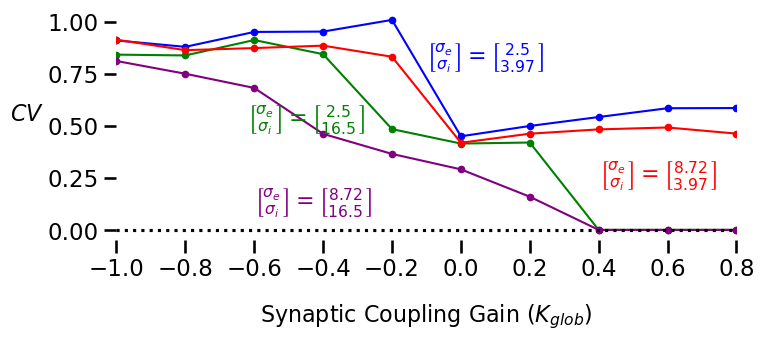

In [25]:
colors= plt.get_cmap('jet')
colorIter = iter(colors(np.linspace(0.3, 1, 4)))

plt.figure(figsize=(8, 3))

plt.plot(kVals, Lyap[:, 0], '.-', color = 'b', linewidth=1.5)
plt.text(-0.1, 0.8, r'$\genfrac{[}{]}{0}{1}{\sigma_e}{\sigma_i} =  \genfrac{[}{]}{0}{1}{2.5}{3.97}$', color = 'b',  fontsize=16)

plt.plot(kVals, Lyap[:, 1], '.-', color = 'g', linewidth=1.5)
plt.text(-0.62, 0.5, r'$\genfrac{[}{]}{0}{1}{\sigma_e}{\sigma_i} =  \genfrac{[}{]}{0}{1}{2.5}{16.5}$', color = 'g',  fontsize=16)

plt.plot(kVals, Lyap[:, 2], '.-', color = 'r', linewidth=1.5)
plt.text(0.4, 0.23, r'$\genfrac{[}{]}{0}{1}{\sigma_e}{\sigma_i} =  \genfrac{[}{]}{0}{1}{8.72}{3.97}$', color = 'r',  fontsize=16)

plt.plot(kVals, Lyap[:, 3], '.-', color = 'purple', linewidth=1.5)
plt.text(-0.6, 0.1, r'$\genfrac{[}{]}{0}{1}{\sigma_e}{\sigma_i} = \genfrac{[}{]}{0}{1}{8.72}{16.5}$', color = 'purple',  fontsize=16)

plt.axhline(y=0, color = 'k', linestyle=':')
plt.ylabel(r"$CV$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Synaptic Coupling Gain $(K_{glob})$", fontsize=16, labelpad=15)
plt.xlim(kMin, max(kVals))
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)
plt.savefig(os.path.join(figureroot, f"Imod_{iE:.3f}mV_K.png"), dpi=300, bbox_inches='tight')
    

In [26]:
seVals

array([ 2.5       ,  3.23684211,  3.97368421,  4.71052632,  5.44736842,
        6.18421053,  6.92105263,  7.65789474,  8.39473684,  9.13157895,
        9.86842105, 10.60526316, 11.34210526, 12.07894737, 12.81578947,
       13.55263158, 14.28947368, 15.02631579, 15.76315789, 16.5       ])

In [33]:
Lyap = np.zeros((kSteps, 3))
sigE = np.zeros((kSteps, 3))
sigI = np.zeros((kSteps, 3))

for path_ in file_paths:
    if f"_{iE + params['i_e2']:.3f}" not in path_:
        continue
    cv_results = abs(pickle.load(open(path_, 'rb')))

    Lyap[:, 0] = cv_results[:, 0, 1]
    Lyap[:, 1] = cv_results[:, 7, 1]
    Lyap[:, 2] = cv_results[:, 19, 1]

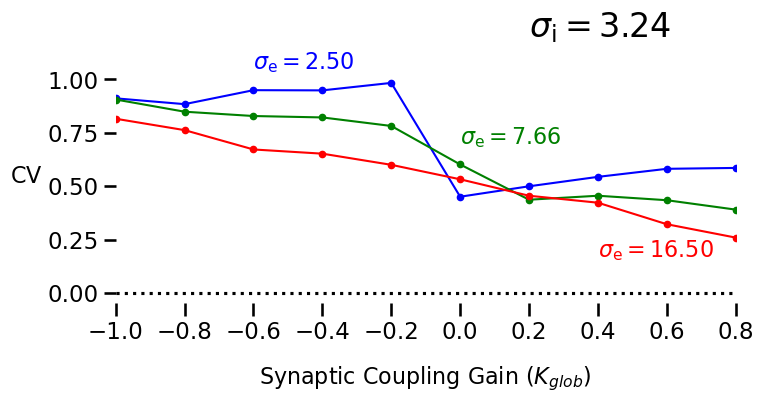

In [34]:
colors= plt.get_cmap('jet')
colorIter = iter(colors(np.linspace(0.3, 1, 4)))

plt.figure(figsize=(8, 3))

plt.plot(kVals, Lyap[:, 0], '.-', color = 'b', linewidth=1.5)
plt.text(-0.6, 1.05, r'$\sigma_{\rm e} = $' + f"{seVals[0]:.2f}", color = 'b',  fontsize=16)

plt.plot(kVals, Lyap[:, 1], '.-', color = 'g', linewidth=1.5)
plt.text(0, 0.7, r'$\sigma_{\rm e} = $' + f"{seVals[7]:.2f}", color = 'g',  fontsize=16)

plt.plot(kVals, Lyap[:, 2], '.-', color = 'r', linewidth=1.5)
plt.text(0.4, 0.17, r'$\sigma_{\rm e} = $' + f"{seVals[19]:.2f}", color = 'r',  fontsize=16)

plt.text(0.2, 1.2, r"$\sigma_{\rm i} = $" + f"{siVals[1]:.2f}", color = 'k',  fontsize=24)

plt.axhline(y=0, color = 'k', linestyle=':')
plt.ylabel(r"$\rm CV$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Synaptic Coupling Gain $(K_{glob})$", fontsize=16, labelpad=15)
plt.xlim(kMin, max(kVals))
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)
plt.savefig(os.path.join(figureroot, f"Imod_{iE:.3f}mV_sigI_{siVals[1]:.2f}_K.png"), dpi=300, bbox_inches='tight')
    

In [35]:
Lyap = np.zeros((kSteps, 3))
sigE = np.zeros((kSteps, 3))
sigI = np.zeros((kSteps, 3))

for path_ in file_paths:
    if f"_{iE + params['i_e2']:.3f}" not in path_:
        continue
    cv_results = abs(pickle.load(open(path_, 'rb')))

    Lyap[:, 0] = cv_results[:, 0, -1]
    Lyap[:, 1] = cv_results[:, 7, -1]
    Lyap[:, 2] = cv_results[:, 19, -1]

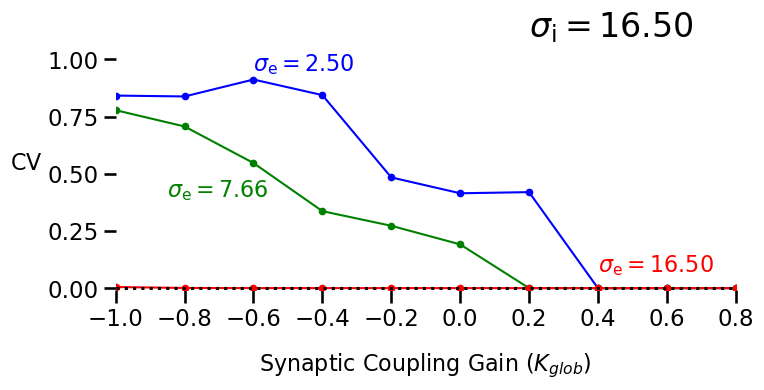

In [37]:
colors= plt.get_cmap('jet')
colorIter = iter(colors(np.linspace(0.3, 1, 4)))

plt.figure(figsize=(8, 3))

plt.plot(kVals, Lyap[:, 0], '.-', color = 'b', linewidth=1.5)
plt.text(-0.6, 0.95, r'$\sigma_{\rm e} = $' + f"{seVals[0]:.2f}", color = 'b',  fontsize=16)

plt.plot(kVals, Lyap[:, 1], '.-', color = 'g', linewidth=1.5)
plt.text(-0.85, 0.4, r'$\sigma_{\rm e} = $' + f"{seVals[7]:.2f}", color = 'g',  fontsize=16)

plt.plot(kVals, Lyap[:, 2], '.-', color = 'r', linewidth=1.5)
plt.text(0.4, 0.07, r'$\sigma_{\rm e} = $' + f"{seVals[19]:.2f}", color = 'r',  fontsize=16)

plt.text(0.2, 1.1, r"$\sigma_{\rm i} = $" + f"{siVals[-1]:.2f}", color = 'k',  fontsize=24)

plt.axhline(y=0, color = 'k', linestyle=':')
plt.ylabel(r"$\rm CV$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Synaptic Coupling Gain $(K_{glob})$", fontsize=16, labelpad=15)
plt.xlim(kMin, max(kVals))
plt.ylim(-0.01, 1)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)
plt.savefig(os.path.join(figureroot, f"Imod_{iE:.3f}mV_sigI_{siVals[-1]:.2f}_K.png"), dpi=300, bbox_inches='tight')
    

In [7]:
_temp = []
_sortpaths = []

for path_ in file_paths:
    Basename = os.path.basename(path_).split('mV.pkl')[0]
    I = float(Basename.split('_I_')[-1])
    _temp.append(I)
    _sortpaths.append(path_)

_temp = np.array(_temp)
Isort = np.argsort(_temp)

_sortpaths = np.array(_sortpaths)
_sortpaths = _sortpaths[Isort]
iVals = _temp[Isort]
iVals -= params['i_e2']

In [8]:
CV = np.zeros((len(_temp), 4))

Kind = 4

for nf, path_ in enumerate(_sortpaths):
    cv_results = abs(pickle.load(open(path_, 'rb')))
 
    CV[nf, 0] = cv_results[Kind, 0, 2]
    CV[nf, 1] = cv_results[Kind, 0, -1]
    CV[nf, 2] = cv_results[Kind, 4, 2]
    CV[nf, 3] = cv_results[Kind, 4, -1]

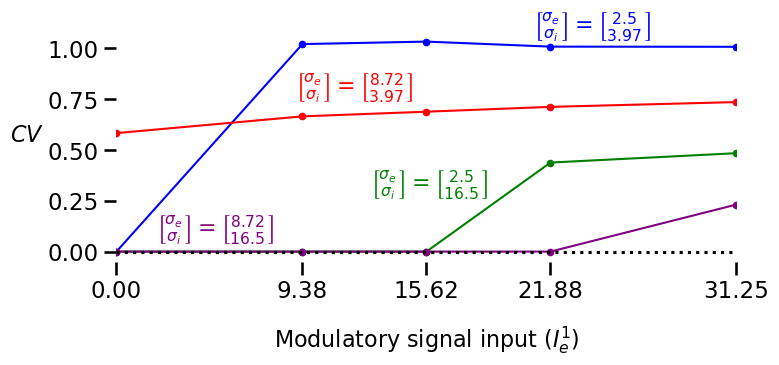

In [9]:
colors= plt.get_cmap('jet')
colorIter = iter(colors(np.linspace(0.3, 1, 4)))

plt.figure(figsize=(8, 3))

plt.plot(iVals, CV[:, 0], '.-', color = 'b', linewidth=1.5)
plt.text(21, 1.08, r'$\genfrac{[}{]}{0}{1}{\sigma_e}{\sigma_i} =  \genfrac{[}{]}{0}{1}{2.5}{3.97}$', color = 'b',  fontsize=16)

plt.plot(iVals, CV[:, 1], '.-', color = 'g', linewidth=1.5)
plt.text(12.8, 0.3, r'$\genfrac{[}{]}{0}{1}{\sigma_e}{\sigma_i} =  \genfrac{[}{]}{0}{1}{2.5}{16.5}$', color = 'g',  fontsize=16)

plt.plot(iVals, CV[:, 2], '.-', color = 'r', linewidth=1.5)
plt.text(9, 0.78, r'$\genfrac{[}{]}{0}{1}{\sigma_e}{\sigma_i} =  \genfrac{[}{]}{0}{1}{8.72}{3.97}$', color = 'r',  fontsize=16)

plt.plot(iVals, CV[:, 3], '.-', color = 'purple', linewidth=1.5)
plt.text(2, 0.08, r'$\genfrac{[}{]}{0}{1}{\sigma_e}{\sigma_i} = \genfrac{[}{]}{0}{1}{8.72}{16.5}$', color = 'purple',  fontsize=16)

plt.axhline(y=0, color = 'k', linestyle=':')
plt.ylabel(r"$CV$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Modulatory signal input $(I^1_e)$", fontsize=16, labelpad=15)
plt.xlim(min(iVals), max(iVals))
plt.xticks(iVals)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)
plt.savefig(os.path.join(figureroot, f"K_{kVals[Kind]:.2f}_Imod.png"), dpi=300, bbox_inches='tight')
    

#### State transition boundary detection

In [10]:
# setting the variables
iPert = [0.  , 0.15, 0.25, 0.35, 0.5] 

kMin = -1; kMax = 1; kSteps = 10
kVals = kMin + np.arange(0, kSteps) / kSteps * (kMax - kMin)

seMin = 2.5; seMax = 16.5; seSteps = 10
seVals = seMin + np.arange(0, seSteps) / (seSteps - 1) * (seMax - seMin)

siMin = 2.5; siMax = 16.5; siSteps = 20
siVals = siMin + np.arange(0, siSteps) / (siSteps - 1) * (siMax - siMin)

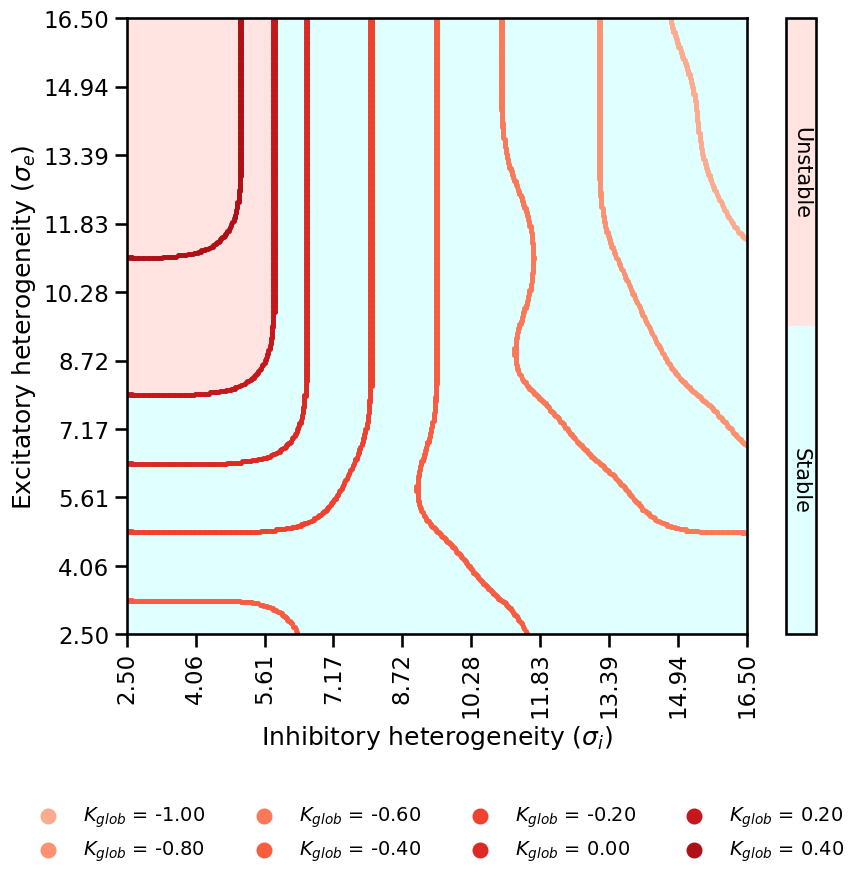

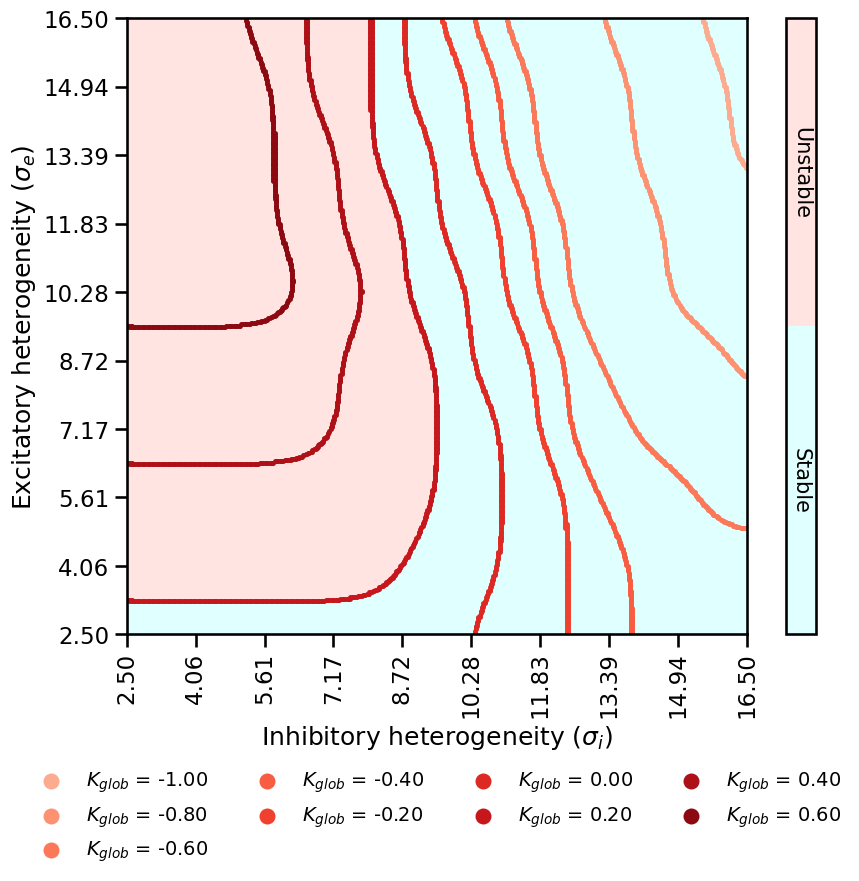

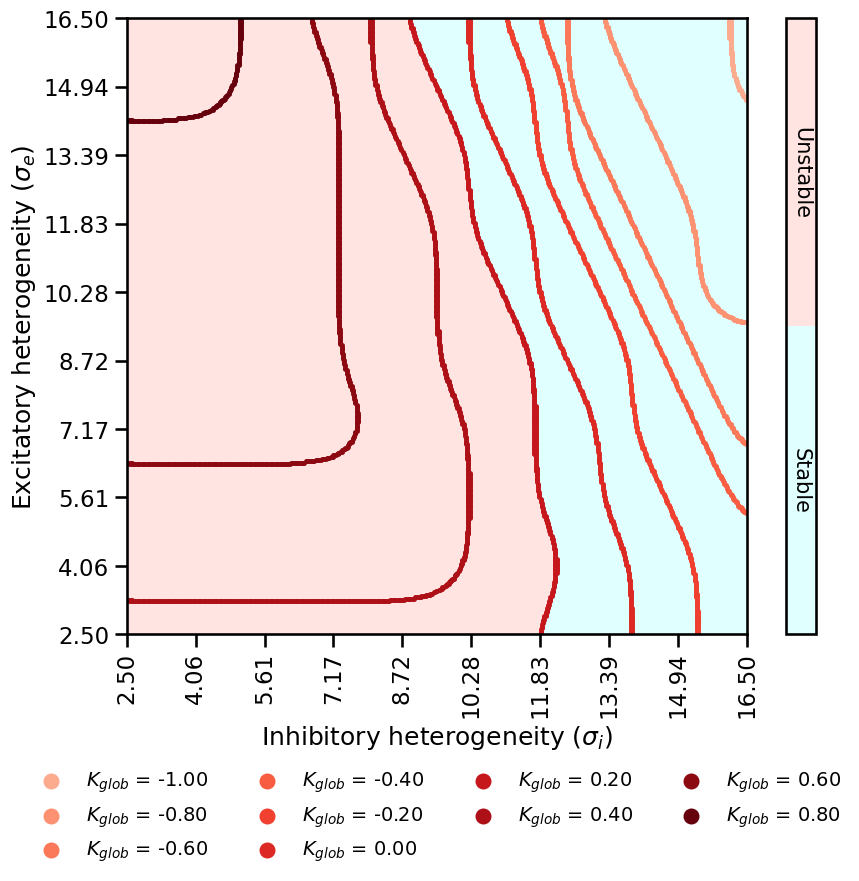

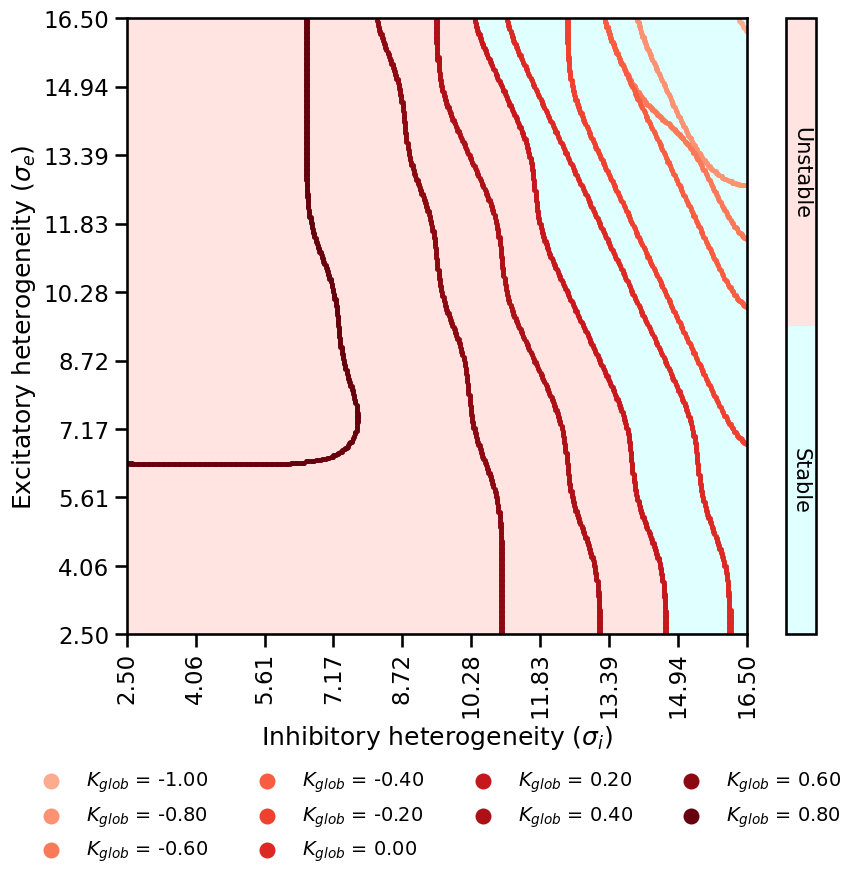

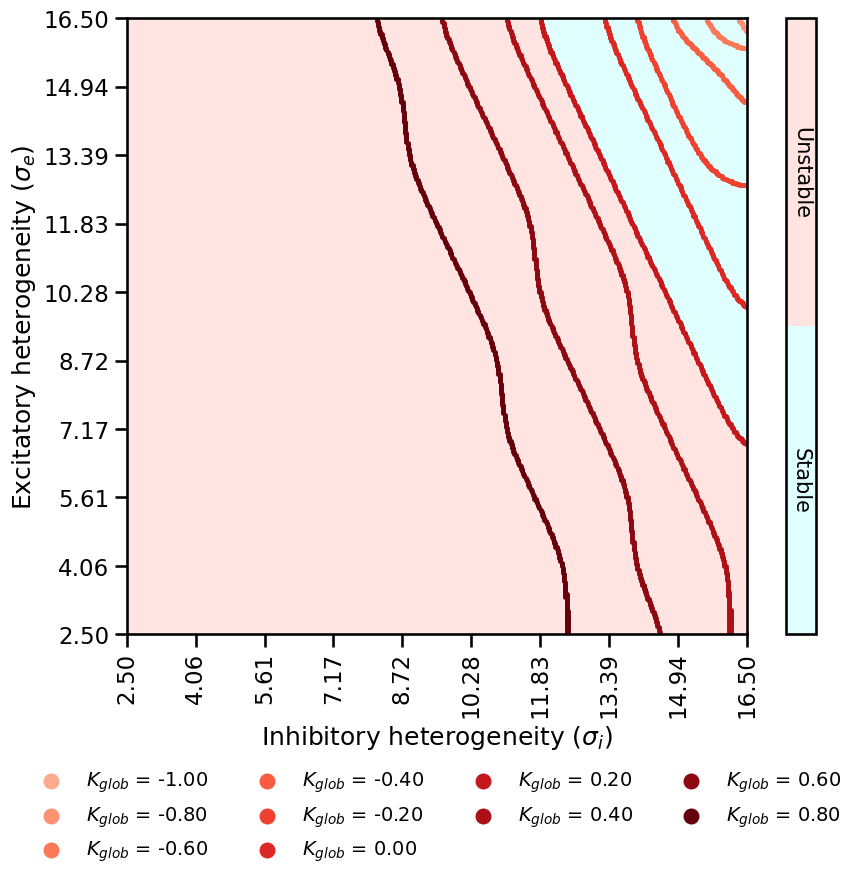

In [12]:
# %%capture
save_str = datetime.datetime(2024, 3, 13)
results_dict = os.path.join('../system_02/results/cvMeasure/', f"exp-{save_str.year}-{save_str.month}-{save_str.day}")

for nI, I in enumerate(iPert):
    file_path = os.path.join(results_dir, f"scenario02_I_{I / params['gamma'] + params['i_e2']:.3f}mV.pkl")

    if not os.path.isfile(file_path):
        print('no files found!')

    else:
        colors= plt.get_cmap('Reds')
        colorIter = iter(colors(np.linspace(0.3, 1, len(kVals))))

        last_response = None
        ifPlot = True
        plt.figure(figsize=(10,8))
        
        cv_results = abs(pickle.load(open(file_path, 'rb')))

        for nf in range(kSteps):
            if round(kVals[nf], 1) == 0.2:
                thresh_map = deepcopy(cv_results[nf, :, :])
                thresh_map[thresh_map > 0.01] = 1
                thresh_map[thresh_map <= 0.01] = -1

                sige_arr, sigi_arr, response_map = cv_upsample(
                                                                orig_response=thresh_map, 
                                                                eval_arrx=siVals, 
                                                                eval_arry=seVals, 
                                                                y_min = seMin, y_max = seMax, 
                                                                x_min = siMin, x_max = siMax, 
                                                                sigma_x = 25, sigma_y = 25,  
                                                                resolution = 500
                                                            )
                
                thresh_map = deepcopy(response_map)
                thresh_map[thresh_map > 0.00] = 1
                thresh_map[thresh_map <= 0.00] = 0

                heatmap = plt.pcolormesh(sigi_arr, sige_arr, thresh_map, cmap=ListedColormap(['lightcyan', 'mistyrose']))
                cbar = plt.colorbar(heatmap)

                cbar.ax.get_yaxis().set_ticks([])
                cbar.ax.text(0.5, .75 , r"Unstable", rotation=270, ha='center', va='center', fontsize=15)
                cbar.ax.text(0.5, 0.25 , r"Stable", rotation=270, ha='center', va='center', fontsize=15)

        for nf in range(kSteps):
            color = next(colorIter)

            thresh_map = deepcopy(cv_results[nf, :, :])
            thresh_map[thresh_map > 0.01] = 1
            thresh_map[thresh_map <= 0.01] = -1

            sige_arr, sigi_arr, response_map = cv_upsample(
                                                            orig_response=thresh_map, 
                                                            eval_arrx=siVals, 
                                                            eval_arry=seVals, 
                                                            y_min = seMin, y_max = seMax, 
                                                            x_min = siMin, x_max = siMax, 
                                                            sigma_x = 25, sigma_y = 25,  
                                                            resolution = 500
                                                        )
    
            thresh_map = deepcopy(response_map)
            thresh_map[thresh_map > 0.00] = 1
            thresh_map[thresh_map <= 0.00] = 0

            edge_boundary, sigi_edges, sige_edges = boundary_detection(thresh_map, sige_arr, sigi_arr)
                
            if not edge_boundary:
                continue

            plt.scatter(sigi_edges, sige_edges, marker='.', s = 16, c = color,  label = r"$K_{glob}$" + f" = {kVals[nf]:.2f}")
        
        plt.xlabel(r"Inhibitory heterogeneity $(\sigma_i)$"); plt.ylabel(r"Excitatory heterogeneity $(\sigma_e)$")
        plt.xticks(np.linspace(2.5, 16.5, 10), rotation = 90); plt.yticks(np.linspace(2.5, 16.5, 10))
        plt.xlim(2.5, 16.5); plt.ylim(2.5, 16.5)
        # plt.title(r"$I^1_e = $" + f"{I - params['i_e2']:.3f}mV")
        plt.legend(loc = 'lower center', bbox_to_anchor=(0.5, -0.4), edgecolor="white", ncols=4, markerscale=5, fontsize=14)
        plt.savefig(os.path.join(figureroot, f"boundarydetection_modulation_Imod_{I / params['gamma']:.3f}mV.png"), dpi = 300, bbox_inches='tight')
        plt.show()